# Clustering

In [283]:
import sklearn.datasets as skd
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
import statsmodels.api as sm
from tqdm.notebook import tqdm
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyagrum
import pyagrum.skbn as skbn
import pyagrum.lib.notebook as gnb

rs = 42

In [284]:
import pickle

with open('finaldataset.pkl', 'rb') as f: data = pickle.load(f)

X_train = data['X_train'] 
y_train = data['y_train']
X_test = data['X_test'] 
y_test = data['y_test']

In [285]:
X_train.head() #dependent variable (default) is already dropped

,loan_amount,term,income,credit_score,ltv,dtir1,loan_limit_cf,loan_limit_ncf,gender_Female,gender_Joint,...,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_not_inst,submission_of_application_to_inst,region_North,region_North-East,region_central,region_south
60258,256500,360.0,5100.0,538,78.201220,47.0,1,0,0,0,...,0,0,0,0,0,1,1,0,0,0
17482,466500,360.0,7860.0,568,80.709343,34.0,1,0,1,0,...,1,0,0,0,1,0,0,0,0,1
97537,96500,180.0,3960.0,562,75.390625,23.0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
78450,336500,240.0,3360.0,700,70.397490,51.0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
56868,326500,360.0,4620.0,659,56.487889,37.0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [286]:
scaler_x = StandardScaler()

## Unfortunately, sklearn's scaler's don't play nice with pandas data frames, so we'll need to 
## Re-assign the index and column names manually

X_train2 = pd.DataFrame(scaler_x.fit_transform(X_train), 
                        columns = X_train.columns.tolist(),
                        index = X_train.index)

X_test2 = pd.DataFrame(scaler_x.transform(X_test),
                        columns = X_test.columns.tolist(),
                        index = X_test.index)

In [287]:
X_train2.head()

,loan_amount,term,income,credit_score,ltv,dtir1,loan_limit_cf,loan_limit_ncf,gender_Female,gender_Joint,...,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_not_inst,submission_of_application_to_inst,region_North,region_North-East,region_central,region_south
60258,-0.397404,0.423829,-0.234287,-1.395692,0.327165,0.837808,0.231981,-0.231981,-0.480291,-0.622206,...,-0.531111,-0.402306,-0.094543,-0.222882,-0.745517,0.745517,0.986334,-0.090406,-0.24889,-0.862687
17482,0.929182,0.423829,0.483659,-1.136721,0.463269,-0.101315,0.231981,-0.231981,2.082072,-0.622206,...,1.882844,-0.402306,-0.094543,-0.222882,1.341352,-1.341352,-1.013855,-0.090406,-0.24889,1.159169
97537,-1.408136,-2.666008,-0.530830,-1.188515,0.174649,-0.895957,0.231981,-0.231981,2.082072,-0.622206,...,-0.531111,-0.402306,-0.094543,-0.222882,-0.745517,0.745517,-1.013855,-0.090406,-0.24889,1.159169
78450,0.107963,-1.636062,-0.686905,0.002751,-0.096304,1.126769,-4.310695,4.310695,-0.480291,-0.622206,...,-0.531111,-0.402306,-0.094543,-0.222882,-0.745517,0.745517,0.986334,-0.090406,-0.24889,-0.862687
56868,0.044792,0.423829,-0.359147,-0.351176,-0.851108,0.115406,0.231981,-0.231981,-0.480291,-0.622206,...,-0.531111,-0.402306,-0.094543,-0.222882,1.341352,-1.341352,-1.013855,-0.090406,-0.24889,1.159169


array([[<Axes: title={'center': 'status'}>]], dtype=object)

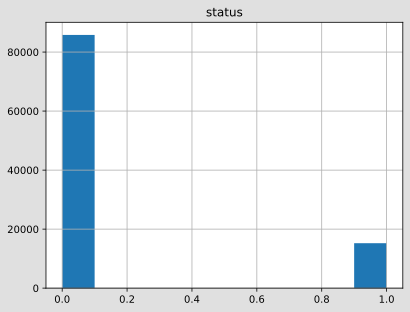

In [288]:
y_train.hist()

In [289]:

## We want 5 clusters, Safe, Low, Medium, Moderate, and High 
kmns = KMeans(n_clusters = 5,
              max_iter = 500, 
              tol = 0.0001,
              init = 'random', 
              n_init = 'auto', 
              random_state = rs)

kmns = kmns.fit(X_train2)

## Generate Predictions
y_train_hat = kmns.predict(X_train2)
y_test_hat = kmns.predict(X_test2)

## The total, negative inertia of the given X sets
kmns.score(X_train2) , kmns.score(X_test2)

(-4958706.468102309, -1319039.2255798364)

In [290]:
X_train2.columns

Index(['loan_amount', 'term', 'income', 'credit_score', 'ltv', 'dtir1',
       'loan_limit_cf', 'loan_limit_ncf', 'gender_Female', 'gender_Joint',
       'gender_Male', 'gender_Sex Not Available', 'approv_in_adv_nopre',
       'approv_in_adv_pre', 'loan_type_type1', 'loan_type_type2',
       'loan_type_type3', 'loan_purpose_p1', 'loan_purpose_p2',
       'loan_purpose_p3', 'loan_purpose_p4', 'credit_worthiness_l1',
       'credit_worthiness_l2', 'business_or_commercial_b/c',
       'business_or_commercial_nob/c', 'neg_ammortization_neg_amm',
       'neg_ammortization_not_neg', 'interest_only_int_only',
       'interest_only_not_int', 'lump_sum_payment_lpsm',
       'lump_sum_payment_not_lpsm', 'construction_type_mh',
       'construction_type_sb', 'occupancy_type_ir', 'occupancy_type_pr',
       'occupancy_type_sr', 'total_units_1U', 'total_units_2U',
       'total_units_3U', 'total_units_4U', 'credit_type_CIB',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       '

In [291]:
X_train2['status'] = y_train['status']
X_test2['status'] = y_test['status']

<Axes: xlabel='Cluster', ylabel='Count'>

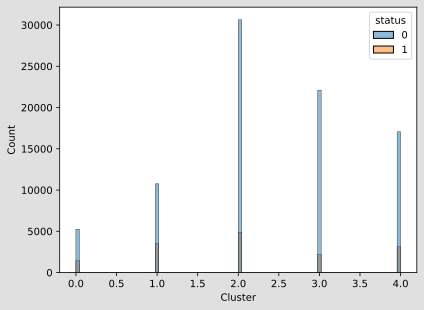

In [292]:
X_train3 = X_train2.copy()
X_train3['Cluster'] = y_train_hat

sns.histplot(data = X_train3,
             x = 'Cluster', hue = 'status')

In [293]:
X_train3.groupby('Cluster')['status'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,6717.0,0.217210,0.412377,0.0,0.0,0.0,0.0,1.0
1,14274.0,0.247023,0.431295,0.0,0.0,0.0,0.0,1.0
2,35525.0,0.137818,0.344714,0.0,0.0,0.0,0.0,1.0
3,24323.0,0.090819,0.287358,0.0,0.0,0.0,0.0,1.0
4,20185.0,0.155214,0.362118,0.0,0.0,0.0,0.0,1.0


<Axes: xlabel='Cluster', ylabel='Count'>

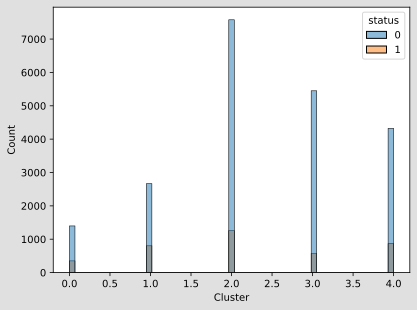

In [294]:
X_test3 = X_test2.copy()
X_test3['Cluster'] = y_test_hat

sns.histplot(data = X_test3, x = 'Cluster', hue = 'status')

In [295]:
X_test3.groupby('Cluster')['status'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,1748.0,0.200801,0.400714,0.0,0.0,0.0,0.0,1.0
1,3467.0,0.231324,0.421740,0.0,0.0,0.0,0.0,1.0
2,8835.0,0.142275,0.349352,0.0,0.0,0.0,0.0,1.0
3,6019.0,0.094700,0.292825,0.0,0.0,0.0,0.0,1.0
4,5188.0,0.166731,0.372771,0.0,0.0,0.0,0.0,1.0


# Decision Tree Classifier with Clustering

In [296]:
## Decision Tree Classifier imports

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

## yes, we need both of these for HGSCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, RandomizedSearchCV, HalvingRandomSearchCV, GridSearchCV

from sklearn.metrics import r2_score, mean_squared_error, precision_score, recall_score, RocCurveDisplay, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, auc
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
import numpy as np
import pandas as pd
import sample_data as sd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.notebook import tqdm

rs = 42

In [297]:
X_train3 = X_train3.drop(columns = ['status'])
X_test3 = X_test3.drop(columns = ['status'])


In [ ]:
## Parameter Grid:
param_grid = {'max_depth': np.arange(2,14,1), 
              'min_samples_leaf': np.arange(2,50,1),
              'min_samples_split': np.arange(2,200,2)} 


dtc = DecisionTreeClassifier(random_state = rs , class_weight = 'balanced')

## Run the Randomized search
sh = RandomizedSearchCV(dtc, 
                         param_grid,
                         n_iter = 100, ## The number of random combinations to try from our parameter grid (sampled with replacement)
                         cv = 5,
                         n_jobs = 2, 
                         scoring = 'accuracy', ## Set prefered scoring method
                         random_state = rs).fit(X_train3 , y_train)
sh.best_estimator_

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(3),
                       min_samples_leaf=np.int64(17),
                       min_samples_split=np.int64(58), random_state=42)

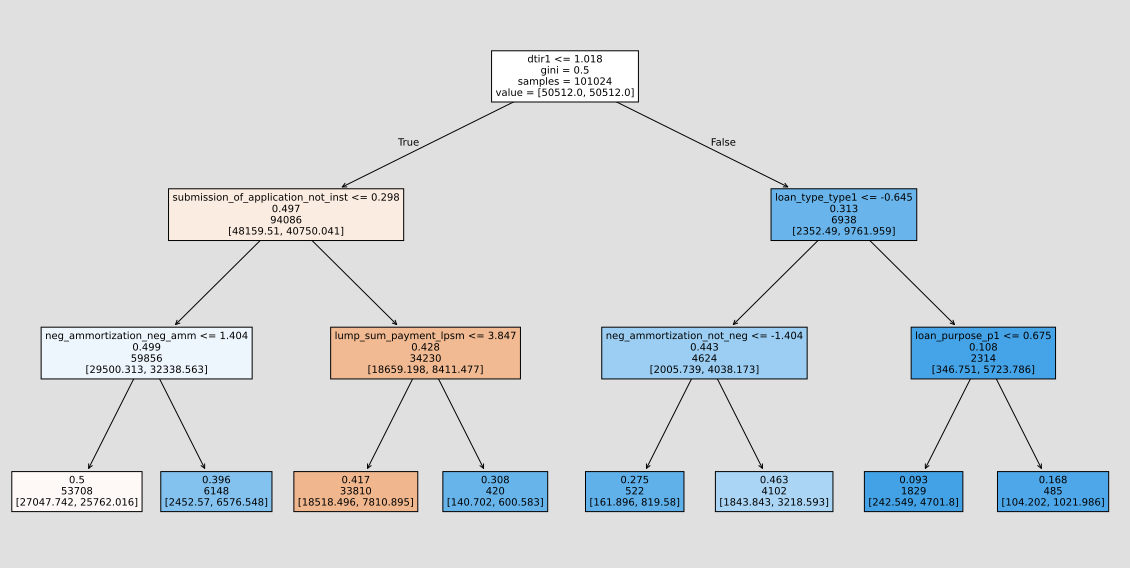

In [ ]:
import sklearn.tree as tree

## Plotting ONLY for Instructional Purposes
## ALMOST NEVER plot the tree in your hw or projects
plt.figure(figsize = (20 , 10))

tree.plot_tree(sh.best_estimator_ , feature_names = X_train3.columns.tolist(), 
               fontsize = 10 , label = 'root' , filled = True)
plt.show()

In [301]:
clf = sh.best_estimator_

clf = clf.fit(X_train3 , y_train)
y_train_hat = clf.predict(X_train3).tolist()
y_test_hat = clf.predict(X_test3).tolist()

## .score on Classifiers gives us accuracy
clf.score(X_train3 , y_train), clf.score(X_test3 , y_test)

(0.816687123851758, 0.8160905887476739)

In [302]:
precision_score(y_train, y_train_hat), precision_score(y_test, y_test_hat)

(0.37798015696727383, 0.38137603795966785)

In [303]:
recall_score(y_train, y_train_hat), recall_score(y_test, y_test_hat)

(0.3353478289430467, 0.33446033810143044)

In [304]:
## What's a 'good' precision or recall score? 
## Ideally: Close to `1.0` but
## Depends on the situation. 
## A good benchmark is always the existing ratio of observations: 
## You'd want the Precision and Recall scores to be much higher 
### than the highest class percentage.
y_train.value_counts()/y_train.shape[0]

status
0         0.849313
1         0.150687
Name: count, dtype: float64

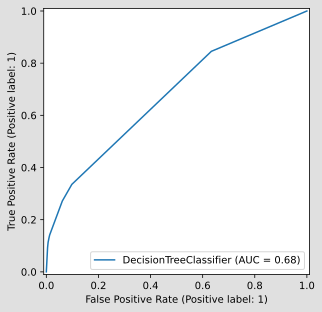

In [305]:
## By default, this plot uses the predicted probabilities, if available
## For DTC, they are, so that is why we get a higher 'AUC' than later with the 
## roc_auc_score function
RocCurveDisplay.from_estimator(clf, X_train3, y_train);

In [306]:
roc_auc_score(y_train, y_train_hat) ## This is the **Actual** area under the ROC curve.

np.float64(0.6187176086009624)

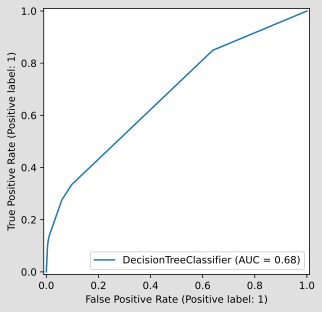

In [307]:
## Few samples in the test set, makes this curve less elegent 
RocCurveDisplay.from_estimator(clf, X_test3, y_test);

In [308]:
roc_auc_score(y_test, y_test_hat)

np.float64(0.618519165874926)

In [309]:
## Pickle the file
data = {
    'X_train': X_train3,
    'y_train': y_train,
    'X_test': X_test3,
    'y_test': y_test
}

# Save to file
with open('7_Clustering.pkl', 'wb') as f:
    pickle.dump(data, f)